In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/Liao_2023_StemLoop_Predictions.csv')

# Parse group (S1–S5) and variant position within group
df['group'] = df['sequence_id'].apply(lambda x: x.split()[0])
df['position'] = df.groupby('group').cumcount()
variant_map = {0: 'Original', 1: 'Structure-Disrupting A', 2: 'Structure-Disrupting B', 3: 'Compensatory A+B'}
df['variant'] = df['position'].map(variant_map)

df.head(8)

,sequence_id,measured_psi,predicted_mfe,spliceai_acceptor,spliceai_donor,pangolin_avg_acceptor_usage,pangolin_avg_donor_usage,alphagenome_psi,group,position,variant
0,S1,0.22,-19.4,0.87,0.94,0.41,0.37,1.00,S1,0,Original
1,S1 34C>A,1.00,-13.7,0.79,0.89,0.32,0.30,1.00,S1,1,Structure-Disrupting A
2,S1 46G>U,1.00,-14.9,0.73,0.85,0.29,0.28,0.99,S1,2,Structure-Disrupting B
3,S1 34C>A 46G>U,0.22,-18.1,0.56,0.74,0.18,0.18,0.97,S1,3,Compensatory A+B
4,S2,0.15,-14.0,0.64,0.70,0.27,0.55,0.81,S2,0,Original
5,S2 39U>G,0.44,-12.3,0.63,0.70,0.33,0.28,0.94,S2,1,Structure-Disrupting A
6,S2 51A>C,0.46,-11.0,0.61,0.68,0.31,0.26,0.90,S2,2,Structure-Disrupting B
7,S2 39U>G 51A>C,0.14,-16.3,0.62,0.68,0.32,0.28,0.92,S2,3,Compensatory A+B


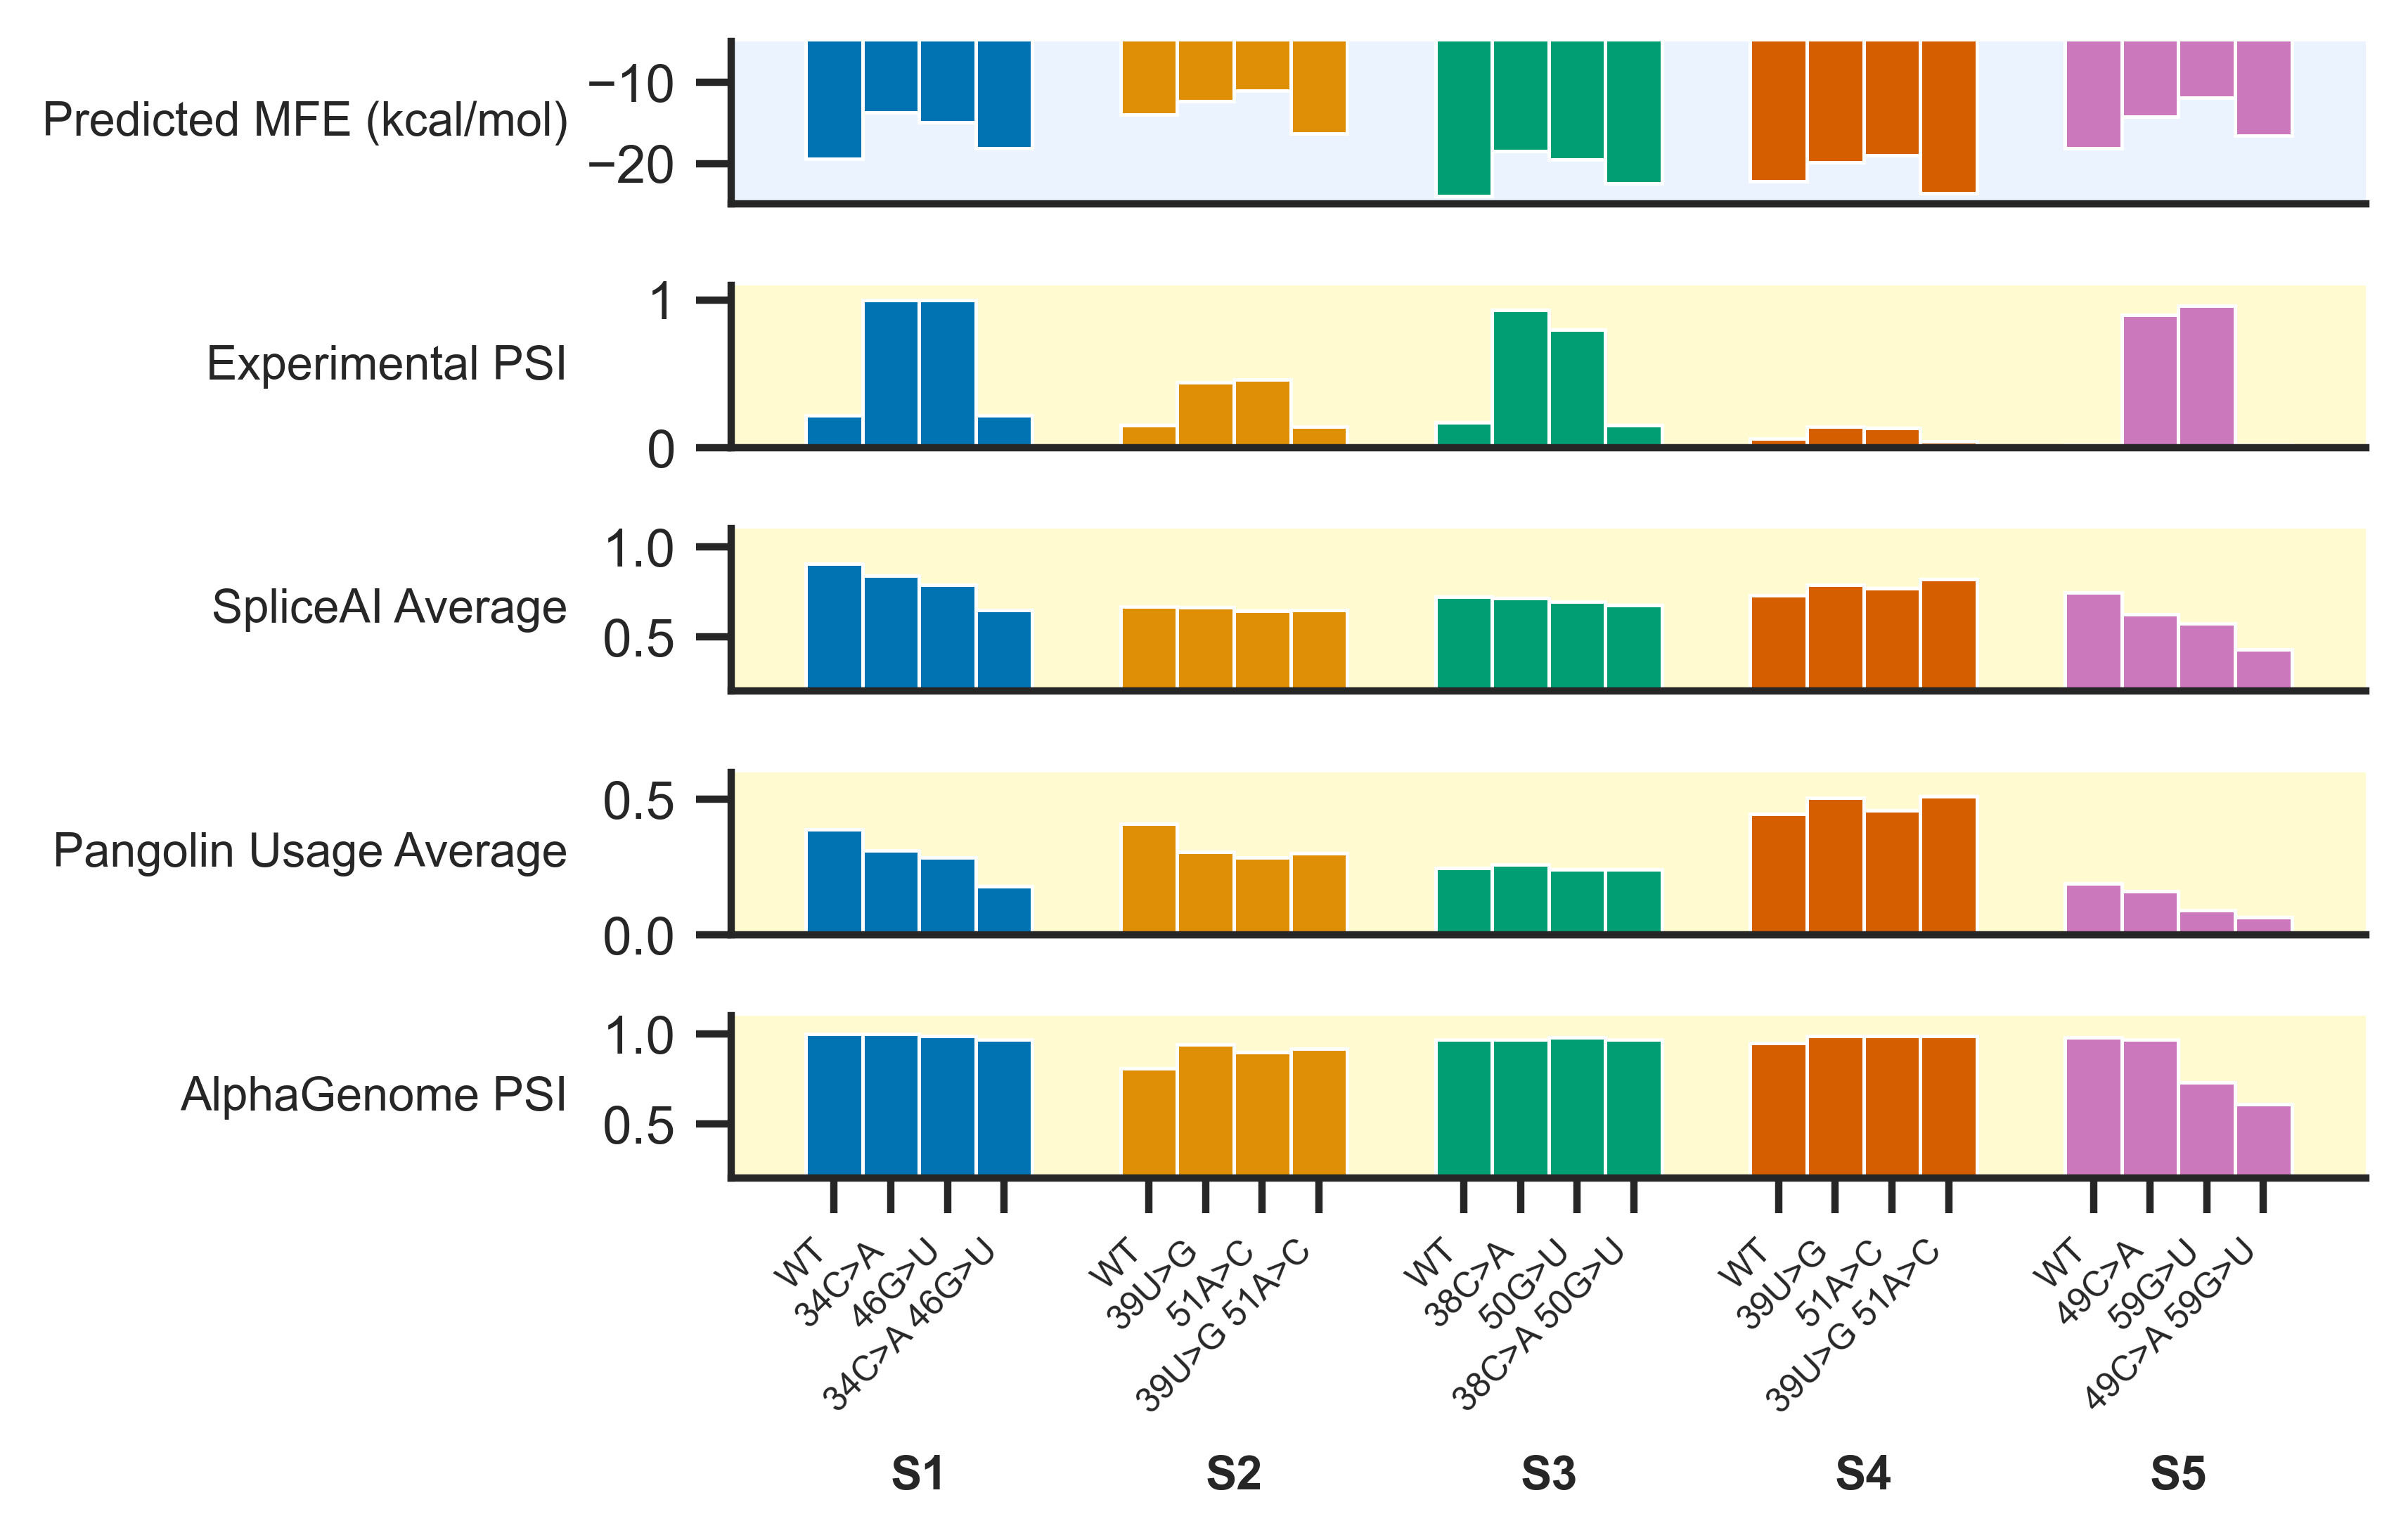

In [3]:
df2 = df.copy()
df2['spliceai_avg']   = (df2['spliceai_acceptor'] + df2['spliceai_donor']) / 2
df2['pangolin_avg']   = (df2['pangolin_avg_acceptor_usage'] + df2['pangolin_avg_donor_usage']) / 2

columns_avg = [
    ('predicted_mfe', 'Predicted MFE (kcal/mol)'),
    ('measured_psi',  'Experimental PSI'),
    ('spliceai_avg',  'SpliceAI Average'),
    ('pangolin_avg',  'Pangolin Usage Average'),
    ('alphagenome_psi','AlphaGenome PSI'),
]
ylims_avg = [
    (-25, -5),
    (0, 1.1),
    (0.2, 1.1),
    (0, 0.6),
    (0.2, 1.1),
]
n_experimental = 1

groups   = ['S1', 'S2', 'S3', 'S4', 'S5']
variants = ['Original', 'Structure-Disrupting A', 'Structure-Disrupting B', 'Compensatory A+B']

sns.set_theme(style='ticks', font='sans-serif', font_scale=1.0)
group_colors = dict(zip(groups, sns.color_palette('colorblind', n_colors=len(groups))))

n_variants = len(variants)
bar_width  = 0.18
group_gap  = 1.0
offsets    = np.linspace(
    -(n_variants - 1) / 2 * bar_width,
     (n_variants - 1) / 2 * bar_width,
    n_variants
)
x_centres = np.arange(len(groups)) * group_gap

fig, axes = plt.subplots(
    nrows=len(columns_avg), ncols=1,
    figsize=(5, .7 * len(columns_avg)),
    sharex=True,
    dpi=600
)
fig.subplots_adjust(hspace=0.5)

for ax_idx, (ax, (col, ylabel), ylim) in enumerate(zip(axes, columns_avg, ylims_avg)):
    if ax_idx < n_experimental:
        ax.set_facecolor('#EAF3FF')
    else:
        ax.set_facecolor('#FFFAD0')

    for g_idx, g in enumerate(groups):
        sub  = df2[df2['group'] == g].sort_values('position')
        xpos = x_centres[g_idx] + offsets
        vals = sub[col].values
        ax.bar(xpos, vals, width=bar_width, color=group_colors[g],
               linewidth=0.6, edgecolor='white', label=g)

    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.set_ylabel(ylabel, fontsize=8, labelpad=6, rotation=0, ha='right', va='center')
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim(ylim)
    ax.tick_params(axis='both', which='major', labelsize=9)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)
    sns.despine(ax=ax)

# Two-level x labels
xpos_all, mut_labels = [], []
for g_idx, g in enumerate(groups):
    for v_idx, variant in enumerate(variants):
        row = df2[(df2['group'] == g) & (df2['variant'] == variant)]
        seq_id = row['sequence_id'].values[0] if len(row) else ''
        parts = seq_id.split(' ', 1)
        mut_labels.append('WT' if len(parts) == 1 else parts[1])
        xpos_all.append(x_centres[g_idx] + offsets[v_idx])

axes[-1].set_xticks(xpos_all)
axes[-1].set_xticklabels(mut_labels, rotation=45, ha='right', fontsize=6)
axes[-1].tick_params(axis='x', bottom=True, labelbottom=True)
for ax in axes[:-1]:
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

for g_idx, g in enumerate(groups):
    axes[-1].text(
        x_centres[g_idx], -1.7, g,
        transform=axes[-1].get_xaxis_transform(),
        ha='center', va='top', fontsize=8, fontweight='bold',
    )

handles = [mpatches.Patch(color=group_colors[g], label=g) for g in groups]
plt.savefig('figures/liao2023_stemloops_predictions.svg', bbox_inches='tight')
plt.show()